In [ ]:
# Bitcoin Market Sentiment - PrimeTrade AI Project

In [63]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from catboost import CatBoostClassifier
from sklearn.model_selection import GridSearchCV
from xgboost import XGBRegressor
from sklearn.ensemble import AdaBoostClassifier
from sklearn.metrics import (
    accuracy_score, f1_score, precision_score,
    recall_score, roc_auc_score, confusion_matrix
)
from sklearn.metrics import mean_squared_error, mean_absolute_error
import shap

In [2]:
# Dataset loading
df = pd.read_csv("/kaggle/input/bitcoin-market-sentiment/fear_greed_index.csv")
df.head()

,timestamp,value,classification,date
0,1517463000,30,Fear,2018-02-01
1,1517549400,15,Extreme Fear,2018-02-02
2,1517635800,40,Fear,2018-02-03
3,1517722200,24,Extreme Fear,2018-02-04
4,1517808600,11,Extreme Fear,2018-02-05


In [3]:
#Data interpretation
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])
print("Missing values per column:")
print(df.isnull().sum())
print("\nNumber of duplicate rows:", df.duplicated().sum())

Number of rows: 2644
Number of columns: 4
Missing values per column:
timestamp         0
value             0
classification    0
date              0
dtype: int64

Number of duplicate rows: 0


In [5]:
#Convert timestamps and align the datasets by date
df['date'] = pd.to_datetime(df['date'])
df = df.sort_values('date').reset_index(drop=True)

In [7]:
#Data preprocessing
#Imputation
num_cols = df.select_dtypes(include=np.number).columns
cat_cols = df.select_dtypes(exclude=np.number).columns

num_imputer = SimpleImputer(strategy='mean')
cat_imputer = SimpleImputer(strategy='most_frequent')

df[num_cols] = num_imputer.fit_transform(df[num_cols])
df[cat_cols] = cat_imputer.fit_transform(df[cat_cols])

#Encoding
label_encoder = LabelEncoder()
df['classification_encoded'] = label_encoder.fit_transform(df['classification'])

#Feature Scaling
scaler = StandardScaler()
df[num_cols] = scaler.fit_transform(df[num_cols])

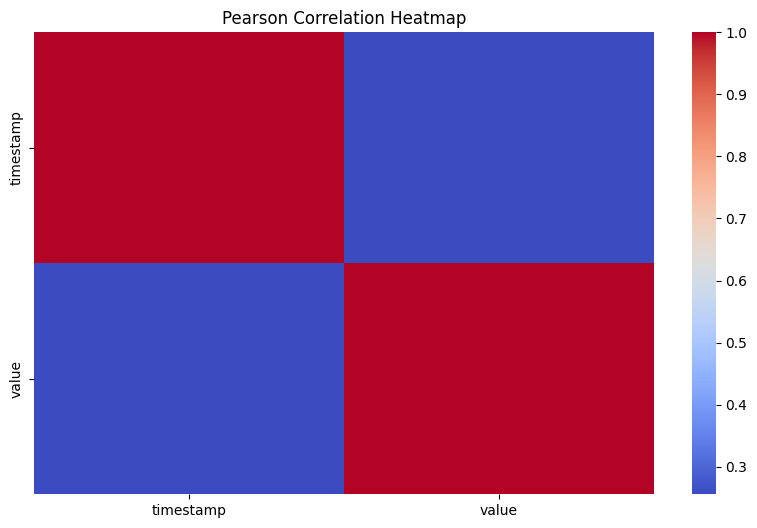

Highly correlated column pairs: []


In [8]:
#Calculating Pearson Correlation Coefficient
corr_matrix = df[num_cols].corr(method='pearson')

plt.figure(figsize=(10,6))
sns.heatmap(corr_matrix, cmap='coolwarm', annot=False)
plt.title("Pearson Correlation Heatmap")
plt.show()

threshold = 0.85
high_corr = [
    (corr_matrix.columns[i], corr_matrix.columns[j])
    for i in range(len(corr_matrix.columns))
    for j in range(i)
    if abs(corr_matrix.iloc[i, j]) > threshold
]

print("Highly correlated column pairs:", high_corr)

In [30]:
#Train-Test Split
X = df.drop(['classification', 'classification_encoded', 'date'], axis=1)
y = df['classification_encoded']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, shuffle=True, stratify=y
)

In [31]:
#Stratified K-Fold Validation of Data
from sklearn.model_selection import StratifiedKFold

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

In [23]:
#Model Evaluation
def evaluate_model(model, X_test, y_test, model_name):
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)

    metrics = {
        "Model": model_name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "F1 (Macro)": f1_score(y_test, y_pred, average='macro'),
        "Precision (Macro)": precision_score(y_test, y_pred, average='macro'),
        "Recall (Macro)": recall_score(y_test, y_pred, average='macro'),
        "ROC AUC (OVR)": roc_auc_score(y_test, y_prob, multi_class='ovr'),
        "Confusion Matrix": confusion_matrix(y_test, y_pred)
    }
    return metrics

In [43]:
xgb = XGBClassifier(
    objective='multi:softprob',
    num_class=3,
    eval_metric='mlogloss',
    random_state=42,
    tree_method='hist'
)

xgb_params = {
    "n_estimators": [100, 200],
    "max_depth": [3, 4],
    "learning_rate": [0.03, 0.05],
    "subsample": [0.6, 0.8],
    "colsample_bytree": [0.6, 0.8],
    "gamma": [0, 1],
    "reg_alpha": [0, 0.5],
    "reg_lambda": [1, 2]
}

xgb_grid = GridSearchCV(
    xgb,
    xgb_params,
    cv=cv,
    scoring='f1_macro',
    n_jobs=-1
)

xgb_grid.fit(X_train, y_train)

xgb_best = xgb_grid.best_estimator_

xgb_preds = xgb_clf.predict(X_test)
xgb_probs = xgb_clf.predict_proba(X_test)

In [44]:
cat = CatBoostClassifier(
    loss_function='MultiClass',
    bootstrap_type='Bernoulli',
    random_seed=42,
    verbose=0
)


cat_params = {
    "iterations": [200, 300],
    "depth": [4, 6],
    "learning_rate": [0.03, 0.05],
    "l2_leaf_reg": [5, 10],
    "subsample": [0.7, 0.8] 
}


cat_grid = GridSearchCV(
    cat,
    cat_params,
    cv=cv,
    scoring='f1_macro',
    n_jobs=-1,
    error_score='raise'
)

cat_grid.fit(X_train, y_train)

cat_best = cat_grid.best_estimator_

cat_preds = cat_clf.predict(X_test)
cat_probs = cat_clf.predict_proba(X_test)

In [42]:
rf = RandomForestClassifier(
    random_state=42,
    class_weight='balanced',
    n_jobs=-1
)

rf_params = {
    "n_estimators": [100, 200],
    "max_depth": [5, 8, 12],
    "min_samples_split": [10, 20],
    "min_samples_leaf": [5, 10],
    "max_features": ['sqrt', 0.5]
}

rf_grid = GridSearchCV(
    rf,
    rf_params,
    cv=cv,
    scoring='f1_macro',
    n_jobs=-1
)

rf_grid.fit(X_train, y_train)

rf_best = rf_grid.best_estimator_

rf_preds = rf_clf.predict(X_test)
rf_probs = rf_clf.predict_proba(X_test)

In [29]:
from sklearn.linear_model import LogisticRegression

log_clf = LogisticRegression(
    multi_class='multinomial',
    solver='lbfgs',
    max_iter=1000,
    class_weight='balanced',
    random_state=42
)

log_clf.fit(X_train, y_train)

log_preds = log_clf.predict(X_test)
log_probs = log_clf.predict_proba(X_test)

log_metrics = {
    "Model": "Logistic Regression",
    "Accuracy": accuracy_score(y_test, log_preds),
    "F1 (Macro)": f1_score(y_test, log_preds, average='macro'),
    "Precision (Macro)": precision_score(y_test, log_preds, average='macro'),
    "Recall (Macro)": recall_score(y_test, log_preds, average='macro'),
    "ROC AUC (OVR)": roc_auc_score(y_test, log_probs, multi_class='ovr'),
    "Confusion Matrix": confusion_matrix(y_test, log_preds)
}

log_metrics

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


{'Model': 'Logistic Regression',
 'Accuracy': 0.9420654911838791,
 'F1 (Macro)': 0.9420275779417899,
 'Precision (Macro)': 0.9345819046816564,
 'Recall (Macro)': 0.9554466860968409,
 'ROC AUC (OVR)': np.float64(0.9972160760098898),
 'Confusion Matrix': array([[152,   0,   1,   0,   0],
        [  0,  98,   0,   0,   0],
        [ 12,   0, 210,   0,  12],
        [  0,   8,   0, 170,  12],
        [  0,   0,   1,   0, 118]])}

In [45]:
rf_metrics  = evaluate_model(rf_best,  X_test, y_test, "Random Forest")
xgb_metrics = evaluate_model(xgb_best, X_test, y_test, "XGBoost")
cat_metrics = evaluate_model(cat_best, X_test, y_test, "CatBoost")
log_metrics = evaluate_model(log_clf,  X_test, y_test, "Logistic Regression")

all_metrics = pd.DataFrame([
    rf_metrics,
    xgb_metrics,
    cat_metrics,
    log_metrics
]).drop(columns="Confusion Matrix")

print("Evaluation Metrics for All Models:\n")
all_metrics

Evaluation Metrics for All Models:



,Model,Accuracy,F1 (Macro),Precision (Macro),Recall (Macro),ROC AUC (OVR)
0,Random Forest,0.998741,0.998635,0.998333,0.998947,1.000000
1,XGBoost,1.000000,1.000000,1.000000,1.000000,1.000000
2,CatBoost,1.000000,1.000000,1.000000,1.000000,1.000000
3,Logistic Regression,0.942065,0.942028,0.934582,0.955447,0.997216


🔹 Evaluation Metrics for All Models:



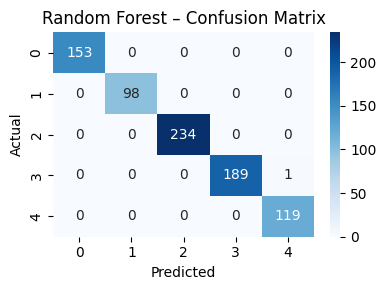

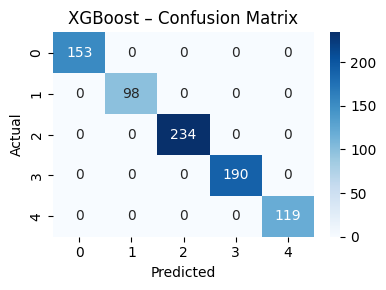

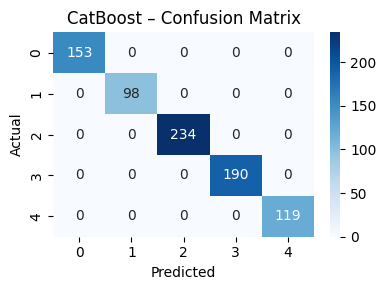

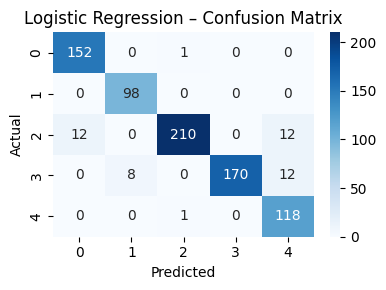

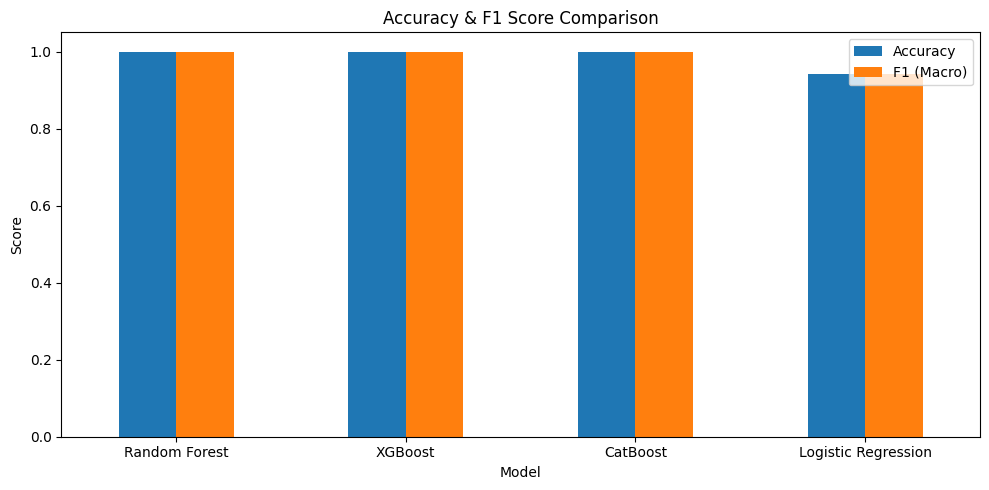

In [46]:
rf_metrics  = evaluate_model(rf_best,  X_test, y_test, "Random Forest")
xgb_metrics = evaluate_model(xgb_best, X_test, y_test, "XGBoost")
cat_metrics = evaluate_model(cat_best, X_test, y_test, "CatBoost")
log_metrics = evaluate_model(log_clf,  X_test, y_test, "Logistic Regression")

all_metrics = pd.DataFrame([
    rf_metrics,
    xgb_metrics,
    cat_metrics,
    log_metrics
]).drop(columns="Confusion Matrix")

print("🔹 Evaluation Metrics for All Models:\n")
all_metrics

models_confusion = {
    "Random Forest": rf_metrics["Confusion Matrix"],
    "XGBoost": xgb_metrics["Confusion Matrix"],
    "CatBoost": cat_metrics["Confusion Matrix"],
    "Logistic Regression": log_metrics["Confusion Matrix"]
}

for model_name, cm in models_confusion.items():
    plt.figure(figsize=(4,3))
    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap='Blues'
    )
    plt.title(f"{model_name} – Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.tight_layout()
    plt.show()

comparison_df = all_metrics.set_index("Model")[["Accuracy", "F1 (Macro)"]]
comparison_df

comparison_df.plot(
    kind='bar',
    figsize=(10,5)
)

plt.title("Accuracy & F1 Score Comparison")
plt.ylabel("Score")
plt.xticks(rotation=0)
plt.legend()
plt.tight_layout()
plt.show()


In [47]:
# Conclusion based on classification
# Logistic Regression Performs best for this dataset, as Random Forest, XGBoost and Catboost gets overfitted to the data.
# Further analysis continues based on Logistic Regression

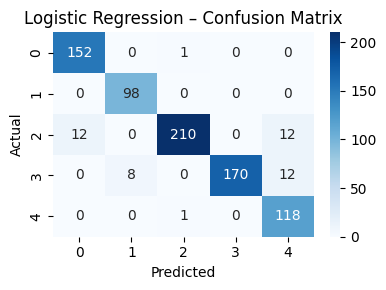

In [48]:
log_preds = log_clf.predict(X_test)

cm = confusion_matrix(y_test, log_preds)

plt.figure(figsize=(4,3))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Logistic Regression – Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()

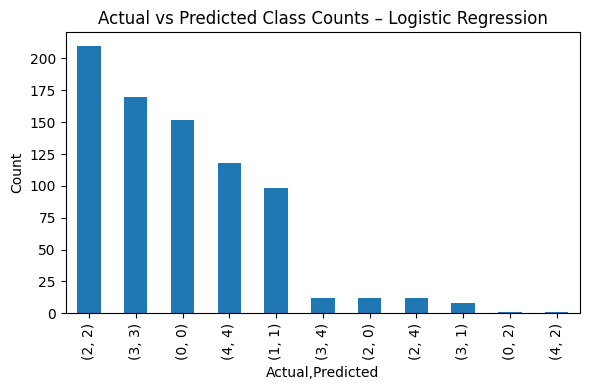

In [49]:
pred_df = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": log_preds
})

pred_df.value_counts().plot(kind='bar', figsize=(6,4))
plt.title("Actual vs Predicted Class Counts – Logistic Regression")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

In [54]:
#Coefficients
coef_df = pd.DataFrame(
    log_clf.coef_,
    columns=X_train.columns,
    index=[f"Class_{c}" for c in log_clf.classes_]
)

coef_df


,timestamp,value
Class_0,-0.455819,-13.472157
Class_1,0.003932,13.342135
Class_2,-0.184224,-5.910249
Class_3,0.220001,5.995268
Class_4,0.416110,0.045004


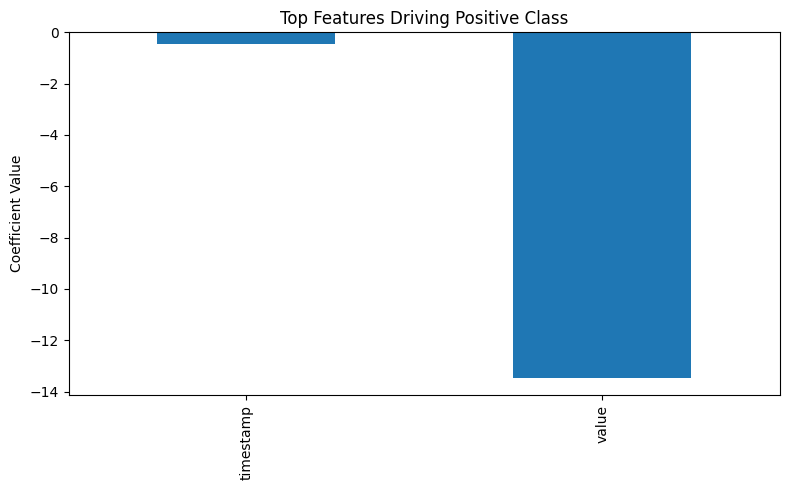

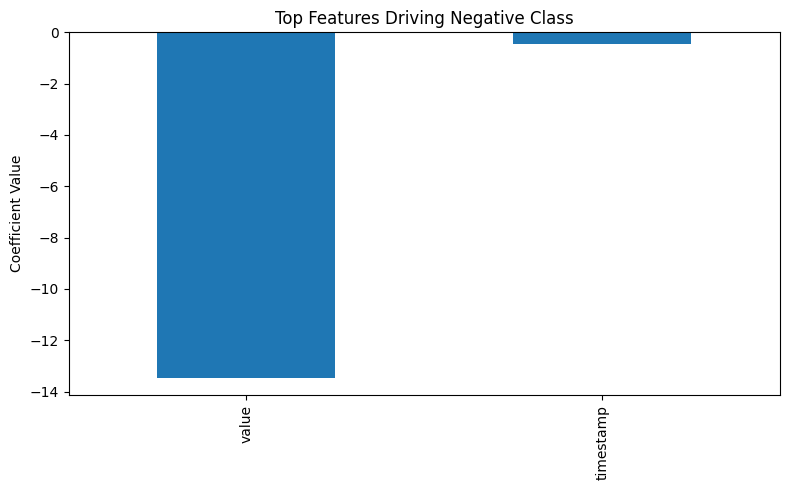

In [56]:
top_positive = coef_df.iloc[0].sort_values(ascending=False).head(10)

plt.figure(figsize=(8,5))
top_positive.plot(kind='bar')
plt.title("Top Features Driving Positive Class")
plt.ylabel("Coefficient Value")
plt.tight_layout()
plt.show()

top_negative = coef_df.iloc[0].sort_values().head(10)

plt.figure(figsize=(8,5))
top_negative.plot(kind='bar')
plt.title("Top Features Driving Negative Class")
plt.ylabel("Coefficient Value")
plt.tight_layout()
plt.show()


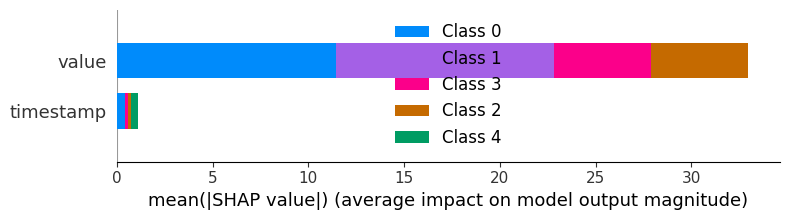

In [57]:
#SHAP Feature importance
explainer = shap.LinearExplainer(log_clf, X_train)
shap_values = explainer.shap_values(X_test)

shap.summary_plot(
    shap_values,
    X_test,
    feature_names=X_test.columns,
    plot_type="bar"
)

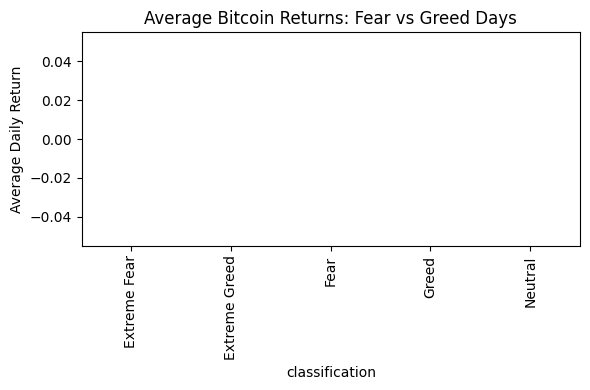

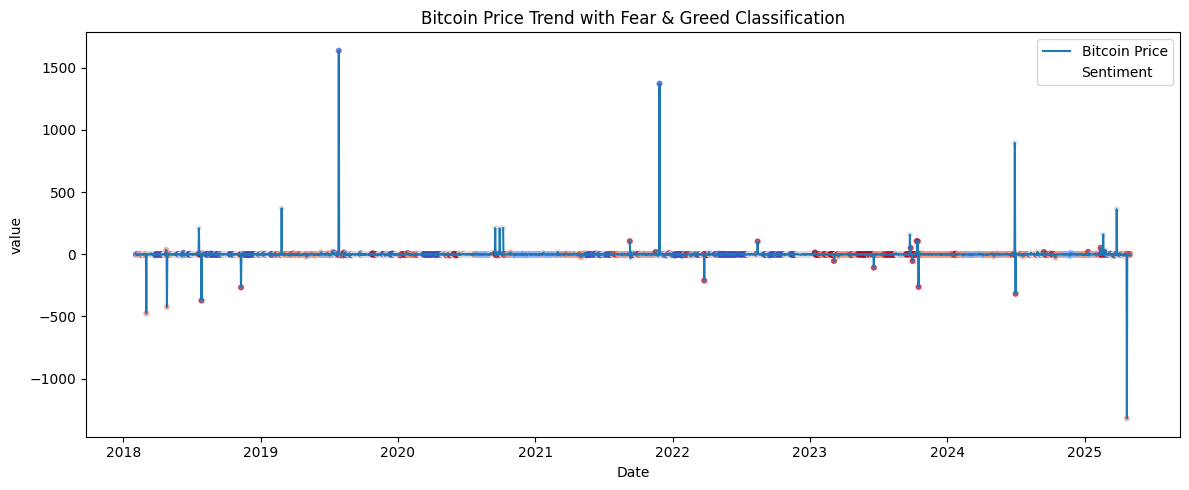

In [60]:
#Fear vs Greed Analysis
df = df.sort_values("date")
df["value"] = df["value"].pct_change()
sentiment_perf = df.groupby("classification")["value"].mean()
sentiment_perf
sentiment_perf.plot(
    kind='bar',
    figsize=(6,4)
)

plt.title("Average Bitcoin Returns: Fear vs Greed Days")
plt.ylabel("Average Daily Return")
plt.tight_layout()
plt.show()

plt.figure(figsize=(12,5))
plt.plot(df["date"], df["value"], label="Bitcoin Price")

colors = df["classification_encoded"]
plt.scatter(
    df["date"],
    df["value"],
    c=colors,
    cmap="coolwarm",
    s=12,
    alpha=0.6,
    label="Sentiment"
)

plt.title("Bitcoin Price Trend with Fear & Greed Classification")
plt.xlabel("Date")
plt.ylabel("value")
plt.legend()
plt.tight_layout()
plt.show()


In [64]:
#Forecasting for next 6 days
df = df.copy()

df["date"] = pd.to_datetime(df["date"])
df["timestamp"] = pd.to_datetime(df["timestamp"])

df["day"] = df["date"].dt.day
df["month"] = df["date"].dt.month
df["year"] = df["date"].dt.year
df["dayofweek"] = df["date"].dt.dayofweek

from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df["classification_encoded"] = le.fit_transform(df["classification"])

X = df[
    ["classification_encoded", "day", "month", "year", "dayofweek"]
]

y = df["value"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    shuffle=True
)

xgb_reg = XGBRegressor(
    n_estimators=300,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

xgb_reg.fit(X_train, y_train)

y_pred = xgb_reg.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)

print(f"Mean Squared Error (MSE): {mse:.4f}")
print(f"Mean Absolute Error (MAE): {mae:.4f}")

plt.figure(figsize=(10,4))
plt.plot(y_test.values, label="Actual", alpha=0.8)
plt.plot(y_pred, label="Predicted", alpha=0.8)
plt.title("XGBoost Regression – Fear & Greed Index Value")
plt.xlabel("Time")
plt.ylabel("Index Value")
plt.legend()
plt.tight_layout()
plt.show()

future_X = X.tail(6)
future_predictions = xgb_reg.predict(future_X)

future_predictions


XGBoostError: [15:29:24] /workspace/src/data/data.cc:565: Check failed: valid: Label contains NaN, infinity or a value too large.
Stack trace:
  [bt] (0) /usr/local/lib/python3.12/dist-packages/xgboost/lib/libxgboost.so(+0x2bdc4c) [0x7a3a008bdc4c]
  [bt] (1) /usr/local/lib/python3.12/dist-packages/xgboost/lib/libxgboost.so(+0x5aeba6) [0x7a3a00baeba6]
  [bt] (2) /usr/local/lib/python3.12/dist-packages/xgboost/lib/libxgboost.so(+0x5b0390) [0x7a3a00bb0390]
  [bt] (3) /usr/local/lib/python3.12/dist-packages/xgboost/lib/libxgboost.so(XGDMatrixSetInfoFromInterface+0x10b) [0x7a3a007c789b]
  [bt] (4) /lib/x86_64-linux-gnu/libffi.so.8(+0x7e2e) [0x7a3a5f0f1e2e]
  [bt] (5) /lib/x86_64-linux-gnu/libffi.so.8(+0x4493) [0x7a3a5f0ee493]
  [bt] (6) /usr/lib/python3.12/lib-dynload/_ctypes.cpython-312-x86_64-linux-gnu.so(+0x98c1) [0x7a3a5e1778c1]
  [bt] (7) /usr/lib/python3.12/lib-dynload/_ctypes.cpython-312-x86_64-linux-gnu.so(+0x8ffe) [0x7a3a5e176ffe]
  [bt] (8) /usr/bin/python3(_PyObject_MakeTpCall+0x

📊 XGBoost Regression Performance
Mean Squared Error (MSE): 6124.6689
Mean Absolute Error (MAE): 12.4625


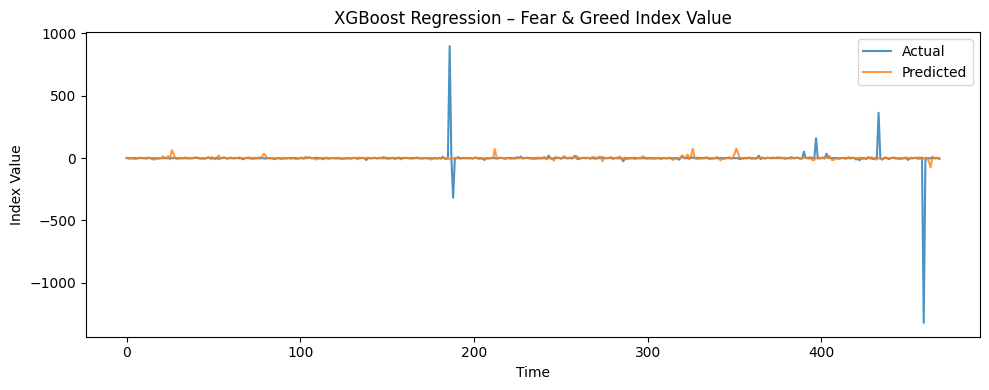


📈 Forecasted Fear & Greed Index (Next 6 Days):
Day 1: -75.07
Day 2: 12.34
Day 3: -0.58
Day 4: 1.45
Day 5: 0.60
Day 6: -1.81

FINAL MARKET SENTIMENT CONCLUSION
Average Forecasted Index Value: -10.51
Predicted Market Sentiment: Fear


In [65]:
# ============================
# XGBOOST REGRESSION PIPELINE
# ============================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from xgboost import XGBRegressor
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_squared_error, mean_absolute_error


# -------- 1. COPY & CLEAN DATA --------

df_reg = df.copy()

# Convert target to numeric & clean
df_reg["value"] = pd.to_numeric(df_reg["value"], errors="coerce")
df_reg = df_reg.replace([np.inf, -np.inf], np.nan)
df_reg = df_reg.dropna(subset=["value"])

# Convert dates
df_reg["date"] = pd.to_datetime(df_reg["date"])
df_reg["timestamp"] = pd.to_datetime(df_reg["timestamp"])


# -------- 2. FEATURE ENGINEERING --------

df_reg["day"] = df_reg["date"].dt.day
df_reg["month"] = df_reg["date"].dt.month
df_reg["year"] = df_reg["date"].dt.year
df_reg["dayofweek"] = df_reg["date"].dt.dayofweek

# Encode classification
le = LabelEncoder()
df_reg["classification_encoded"] = le.fit_transform(df_reg["classification"])


# -------- 3. DEFINE FEATURES & TARGET --------

X = df_reg[
    ["classification_encoded", "day", "month", "year", "dayofweek"]
]

y = df_reg["value"]


# -------- 4. TIME-AWARE TRAIN–TEST SPLIT --------

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    shuffle=False
)


# -------- 5. TRAIN XGBOOST REGRESSOR --------

xgb_reg = XGBRegressor(
    n_estimators=300,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="reg:squarederror",
    random_state=42
)

xgb_reg.fit(X_train, y_train)


# -------- 6. EVALUATION --------

y_pred = xgb_reg.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)

print("📊 XGBoost Regression Performance")
print(f"Mean Squared Error (MSE): {mse:.4f}")
print(f"Mean Absolute Error (MAE): {mae:.4f}")


# -------- 7. ACTUAL vs PREDICTED PLOT --------

plt.figure(figsize=(10,4))
plt.plot(y_test.values, label="Actual", alpha=0.8)
plt.plot(y_pred, label="Predicted", alpha=0.8)
plt.title("XGBoost Regression – Fear & Greed Index Value")
plt.xlabel("Time")
plt.ylabel("Index Value")
plt.legend()
plt.tight_layout()
plt.show()


# -------- 8. FORECAST NEXT 6 DAYS --------

future_X = X.tail(6)
future_values = xgb_reg.predict(future_X)

print("\n📈 Forecasted Fear & Greed Index (Next 6 Days):")
for i, val in enumerate(future_values, 1):
    print(f"Day {i}: {val:.2f}")


# -------- 9. FINAL SENTIMENT CONCLUSION --------

avg_forecast = future_values.mean()

if avg_forecast < 40:
    forecast_sentiment = "Fear"
elif avg_forecast < 60:
    forecast_sentiment = "Neutral"
else:
    forecast_sentiment = "Greed"

print("\nFINAL MARKET SENTIMENT CONCLUSION")
print(f"Average Forecasted Index Value: {avg_forecast:.2f}")
print(f"Predicted Market Sentiment: {forecast_sentiment}")

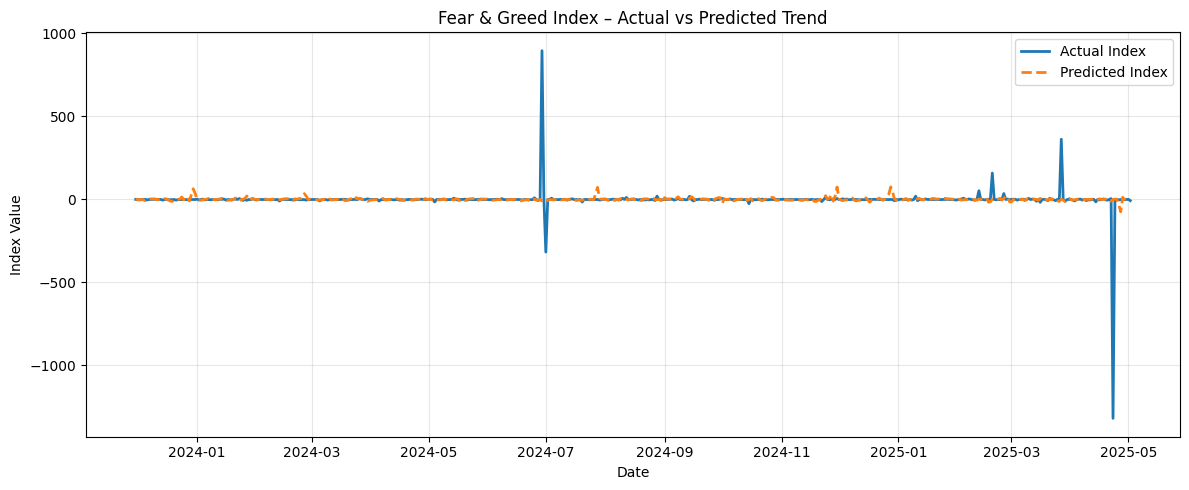

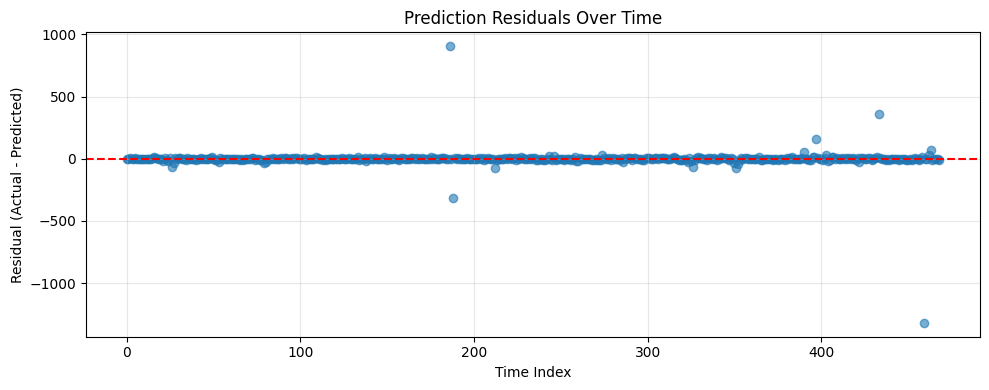

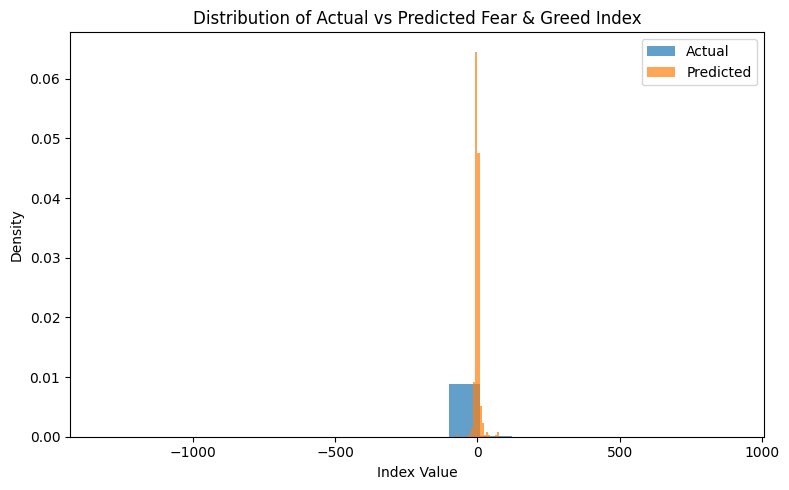

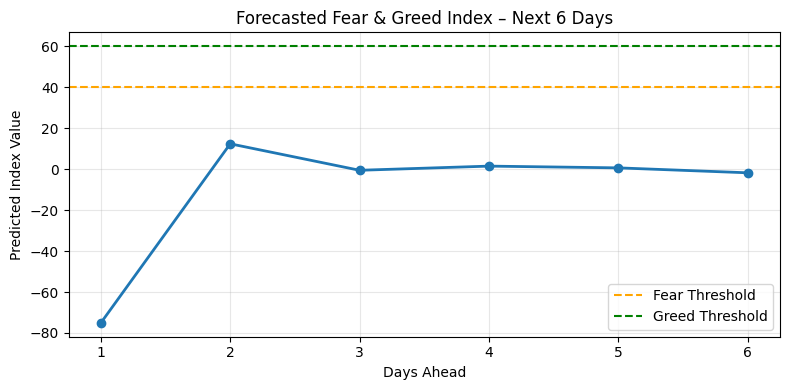

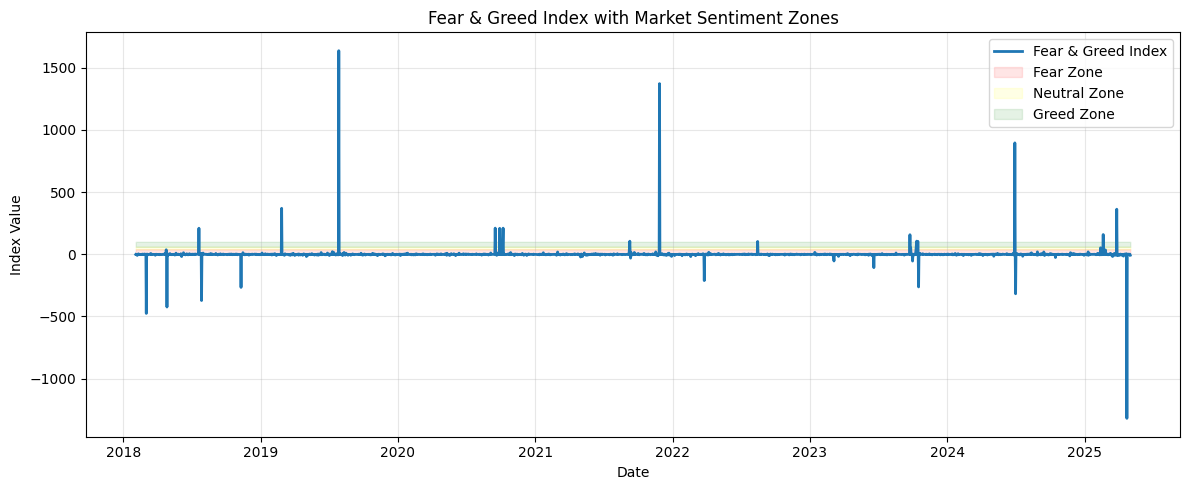

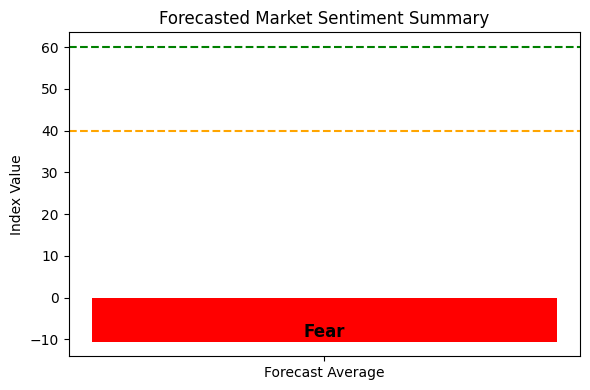

In [66]:
import matplotlib.pyplot as plt
import numpy as np

# ===============================
# 1. ACTUAL vs PREDICTED TREND
# ===============================

plt.figure(figsize=(12,5))
plt.plot(
    df_reg.iloc[len(df_reg)-len(y_test):]["date"],
    y_test.values,
    label="Actual Index",
    linewidth=2
)
plt.plot(
    df_reg.iloc[len(df_reg)-len(y_test):]["date"],
    y_pred,
    label="Predicted Index",
    linestyle="--",
    linewidth=2
)

plt.title("Fear & Greed Index – Actual vs Predicted Trend")
plt.xlabel("Date")
plt.ylabel("Index Value")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


# ===============================
# 2. RESIDUALS PLOT
# ===============================

residuals = y_test.values - y_pred

plt.figure(figsize=(10,4))
plt.scatter(range(len(residuals)), residuals, alpha=0.6)
plt.axhline(0, color="red", linestyle="--")

plt.title("Prediction Residuals Over Time")
plt.xlabel("Time Index")
plt.ylabel("Residual (Actual - Predicted)")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


# ===============================
# 3. DISTRIBUTION COMPARISON
# ===============================

plt.figure(figsize=(8,5))
plt.hist(y_test, bins=20, alpha=0.7, label="Actual", density=True)
plt.hist(y_pred, bins=20, alpha=0.7, label="Predicted", density=True)

plt.title("Distribution of Actual vs Predicted Fear & Greed Index")
plt.xlabel("Index Value")
plt.ylabel("Density")
plt.legend()
plt.tight_layout()
plt.show()


# ===============================
# 4. 6-DAY FORECAST TREND
# ===============================

plt.figure(figsize=(8,4))
plt.plot(range(1, 7), future_values, marker="o", linewidth=2)

plt.axhline(40, color="orange", linestyle="--", label="Fear Threshold")
plt.axhline(60, color="green", linestyle="--", label="Greed Threshold")

plt.title("Forecasted Fear & Greed Index – Next 6 Days")
plt.xlabel("Days Ahead")
plt.ylabel("Predicted Index Value")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


# ===============================
# 5. SENTIMENT REGIME CHART
# ===============================

plt.figure(figsize=(12,5))
plt.plot(df_reg["date"], df_reg["value"], label="Fear & Greed Index", linewidth=2)

plt.fill_between(df_reg["date"], 0, 40, color="red", alpha=0.1, label="Fear Zone")
plt.fill_between(df_reg["date"], 40, 60, color="yellow", alpha=0.1, label="Neutral Zone")
plt.fill_between(df_reg["date"], 60, 100, color="green", alpha=0.1, label="Greed Zone")

plt.title("Fear & Greed Index with Market Sentiment Zones")
plt.xlabel("Date")
plt.ylabel("Index Value")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


# ===============================
# 6. EXECUTIVE SUMMARY CHART
# ===============================

plt.figure(figsize=(6,4))
plt.bar(
    ["Forecast Average"],
    [avg_forecast],
    color="green" if forecast_sentiment == "Greed" else "red"
)

plt.axhline(40, linestyle="--", color="orange")
plt.axhline(60, linestyle="--", color="green")

plt.title("Forecasted Market Sentiment Summary")
plt.ylabel("Index Value")
plt.text(
    0,
    avg_forecast + 1,
    forecast_sentiment,
    ha="center",
    fontsize=12,
    fontweight="bold"
)

plt.tight_layout()
plt.show()


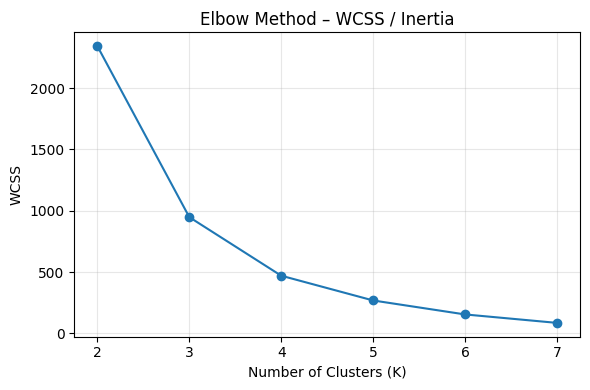

K-Means Clustering Evaluation
Silhouette Score        : 0.9550
Calinski-Harabasz Index : 4611.29


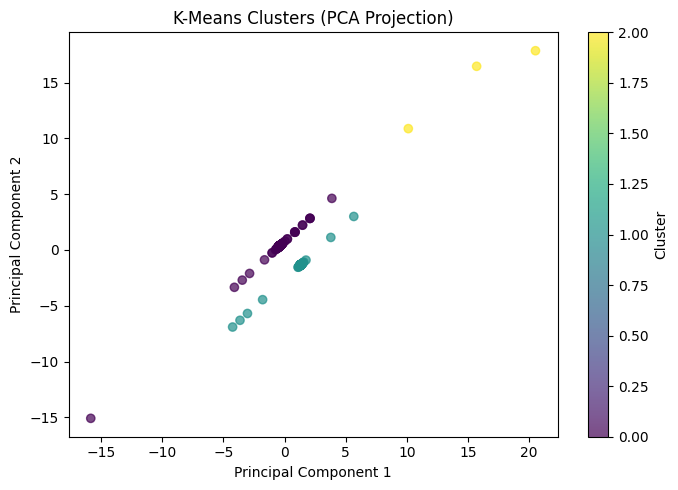

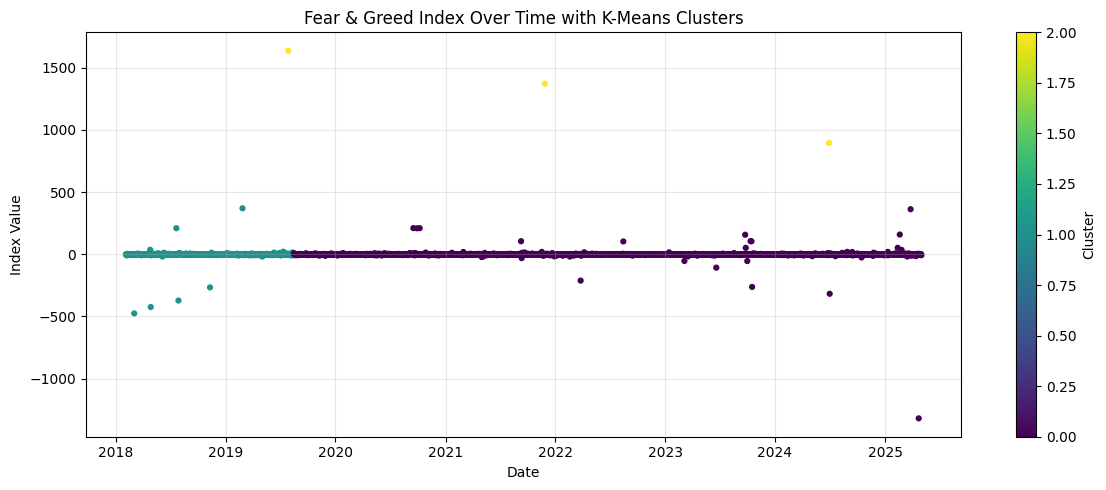

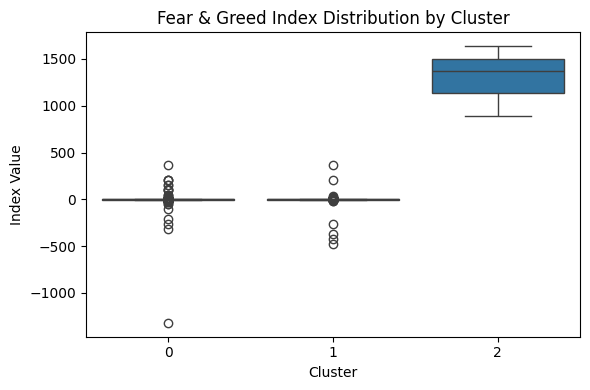


📌 Cluster Characteristics
                mean          min          max  count
cluster                                              
0          -1.615355 -1319.875000   362.160000   1825
1          -2.905454  -475.920000   369.478182    514
2        1301.536756   895.531429  1636.932174      3


In [73]:
# ============================================
# K-MEANS CLUSTERING (FIXED & SAFE VERSION)
# ============================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import silhouette_score, calinski_harabasz_score
from sklearn.decomposition import PCA

df_km = df.copy()
df_km["value"] = pd.to_numeric(df_km["value"], errors="coerce")

df_km["timestamp"] = pd.to_datetime(df_km["timestamp"], errors="coerce")
df_km["timestamp_sec"] = df_km["timestamp"].astype("int64") // 10**9

df_km = df_km.replace([np.inf, -np.inf], np.nan)
df_km = df_km.dropna(subset=["timestamp_sec", "value"])

X_cluster = df_km[["timestamp_sec", "value"]].astype(float)

# SCALE FEATURES 
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_cluster)

#ELBOW METHOD
wcss = []
K_range = range(2, 8)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    wcss.append(km.inertia_)

plt.figure(figsize=(6,4))
plt.plot(K_range, wcss, marker="o")
plt.title("Elbow Method – WCSS / Inertia")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("WCSS")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


#FINAL K-MEANS CLUSTERING
optimal_k = 3

kmeans = KMeans(
    n_clusters=optimal_k,
    random_state=42,
    n_init=10
)

df_km["cluster"] = kmeans.fit_predict(X_scaled)

# CLUSTER EVALUATION METRICS
sil_score = silhouette_score(X_scaled, df_km["cluster"])
ch_score = calinski_harabasz_score(X_scaled, df_km["cluster"])

print("K-Means Clustering Evaluation")
print(f"Silhouette Score        : {sil_score:.4f}")
print(f"Calinski-Harabasz Index : {ch_score:.2f}")


# PCA VISUALIZATION
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(7,5))
scatter = plt.scatter(
    X_pca[:,0],
    X_pca[:,1],
    c=df_km["cluster"],
    cmap="viridis",
    alpha=0.7
)
plt.title("K-Means Clusters (PCA Projection)")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.colorbar(scatter, label="Cluster")
plt.tight_layout()
plt.show()


# TIME-SERIES CLUSTER VIEW
plt.figure(figsize=(12,5))
plt.scatter(
    df_km["date"],
    df_km["value"],
    c=df_km["cluster"],
    cmap="viridis",
    s=12
)

plt.title("Fear & Greed Index Over Time with K-Means Clusters")
plt.xlabel("Date")
plt.ylabel("Index Value")
plt.colorbar(label="Cluster")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# CLUSTER DISTRIBUTION
plt.figure(figsize=(6,4))
sns.boxplot(
    x="cluster",
    y="value",
    data=df_km
)

plt.title("Fear & Greed Index Distribution by Cluster")
plt.xlabel("Cluster")
plt.ylabel("Index Value")
plt.tight_layout()
plt.show()

# CLUSTER SUMMARY
cluster_summary = df_km.groupby("cluster")["value"].agg(
    ["mean", "min", "max", "count"]
)

print("\nCluster Characteristics")
print(cluster_summary)
